# Análisis Bayesiano — Impacto del AGN sobre la metalicidad post-merger

**Taller de Estadística Evolutiva — Ramiro Santamaria, Abril 2026**

Este notebook implementa el modelo lineal bayesiano jerárquico para estimar el efecto
del AGN y los mergers sobre el cambio relativo de metalicidad gaseosa
($\Delta$ 12+log(O/H)) usando las simulaciones EAGLE.

**Grupos de galaxias:**

| Grupo | Merger | AGN | Simulación |
|-------|--------|-----|------------|
| A | ✓ | ✓ | RefL0100N1504 |
| B | ✗ | ✓ | RefL0100N1504 |
| C | ✓ | ✗ | NoAGNL0050N0752 |
| D | ✗ | ✗ | NoAGNL0050N0752 |

**Variable dependiente:** `12+log(O/H)_unif` = cambio relativo de metalicidad respecto al estado pre-merger (Delta_Snap = -2).

**Predictores:** `Delta_Snap`, `has_merger`, `has_AGN`, `Fgas_unif`, `log_Mstar_unif`.


## 1. Imports y configuración

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

import pymc as pm
import arviz as az
import pytensor.tensor as pt
import pytensor

# Semilla para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paleta de colores por grupo
COLORS = {"A": "#E63946", "B": "#457B9D", "C": "#F4A261", "D": "#2A9D8F"}
LABELS = {
    "A": "A: Merger + AGN",
    "B": "B: No Merger + AGN",
    "C": "C: Merger + NoAGN",
    "D": "D: No Merger + NoAGN",
}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F8F9FA",
    "axes.grid": True, "grid.color": "#E0E0E0", "grid.linewidth": 0.6,
    "font.family": "DejaVu Sans", "font.size": 11,
})

print(f"PyMC versión: {pm.__version__}")
print(f"ArviZ versión: {az.__version__}")


PyMC versión: 6.0.1
ArviZ versión: 1.1.0


In [9]:
print(pytensor.config.cxx)

## 2. Carga y preparación del dataset

In [10]:
# ─── Carga de los 4 grupos ───────────────────────────────────────────────────
BASE = "data/"  # Ajustar al path local si es necesario

dfs_raw = {
    "A": pd.read_csv(BASE + "AGN_Merger_A.csv"),
    "B": pd.read_csv(BASE + "AGN_NoMerger_B.csv"),
    "C": pd.read_csv(BASE + "NoAGN_Merger_C.csv"),
    "D": pd.read_csv(BASE + "NoAGN_NoMerger_D.csv"),
}

# ─── Añadir indicadores de grupo ─────────────────────────────────────────────
for g, df in dfs_raw.items():
    df["Grupo"]      = g
    df["has_merger"] = 1 if g in ["A", "C"] else 0
    df["has_AGN"]    = 1 if g in ["A", "B"] else 0

# ─── Unificar columnas comunes ───────────────────────────────────────────────
cols = ["RootGalaxyID", "Delta_Snap", "Delta_Time_Gyr",
        "12+log(O/H)_unif", "Fgas_unif", "log_Mstar_unif",
        "Grupo", "has_merger", "has_AGN"]

partes = []
for g, df in dfs_raw.items():
    sub = df[cols].copy()
    sub["log_MBH_Mstar_unif"] = df["log_MBH_Mstar_unif"] if "log_MBH_Mstar_unif" in df.columns else np.nan
    partes.append(sub)

df_all = pd.concat(partes, ignore_index=True)

# ─── Filtrar: solo snaps post-merger (>= 0) y sin NaN en la variable objetivo ─
df_post = (
    df_all[df_all["Delta_Snap"] >= 0]
    .dropna(subset=["12+log(O/H)_unif", "Fgas_unif", "log_Mstar_unif"])
    .copy()
)

# ─── Centrado de predictores continuos (recomendado para modelos jerárquicos) ─
df_post["Delta_Snap_c"]   = df_post["Delta_Snap"]     - df_post["Delta_Snap"].mean()
df_post["Fgas_unif_c"]    = df_post["Fgas_unif"]     - df_post["Fgas_unif"].mean()
df_post["Mstar_unif_c"]   = df_post["log_Mstar_unif"] - df_post["log_Mstar_unif"].mean()

# ─── Índice de galaxia (nivel 2 jerárquico) ──────────────────────────────────
galaxias_unicas = df_post["RootGalaxyID"].unique()
gal_idx_map     = {gid: i for i, gid in enumerate(galaxias_unicas)}
df_post["gal_idx"] = df_post["RootGalaxyID"].map(gal_idx_map)
N_galaxias = len(galaxias_unicas)

print("Dataset post-merger listo:")
print(f"  Filas totales: {len(df_post):,}")
print(f"  Galaxias únicas (nivel jerárquico): {N_galaxias}")
print()
print(df_post.groupby("Grupo")[["RootGalaxyID"]].nunique().rename(columns={"RootGalaxyID": "N_galaxias"}))
print()
print(df_post[["12+log(O/H)_unif","Fgas_unif","log_Mstar_unif","Delta_Snap"]].describe().round(3))


Dataset post-merger listo:
  Filas totales: 8,904
  Galaxias únicas (nivel jerárquico): 870

       N_galaxias
Grupo            
A             393
B             339
C              78
D              60

       12+log(O/H)_unif  Fgas_unif  log_Mstar_unif  Delta_Snap
count          8904.000   8904.000        8904.000    8904.000
mean              0.316     -0.279           0.636       4.941
std               0.220      0.167           0.393       3.408
min              -0.679     -0.769          -0.012       0.000
25%               0.162     -0.395           0.339       2.000
50%               0.297     -0.269           0.568       5.000
75%               0.459     -0.159           0.871       8.000
max               1.142      0.365           2.300      14.000


## 3. Prior Predictive Check

Antes de condicionar en los datos verificamos que las distribuciones a priori
generen trayectorias de metalicidad físicamente plausibles.
Esto también nos permite detectar a priori demasiado restrictivas o demasiado difusas.


In [12]:
# ─── Vectores de datos para PyMC ─────────────────────────────────────────────
y_obs        = df_post["12+log(O/H)_unif"].values.astype(float)
snap_c       = df_post["Delta_Snap_c"].values.astype(float)
merger_idx   = df_post["has_merger"].values.astype(int)
agn_idx      = df_post["has_AGN"].values.astype(int)
fgas_c       = df_post["Fgas_unif_c"].values.astype(float)
mstar_c      = df_post["Mstar_unif_c"].values.astype(float)
gal_idx_vec  = df_post["gal_idx"].values.astype(int)

# ─── Modelo para Prior Predictive Check ──────────────────────────────────────
with pm.Model() as modelo_bayesiano:

    # ── Hiperparámetros (nivel población) ────────────────────────────────────
    mu_alpha  = pm.Normal("mu_alpha",  mu=0.25, sigma=0.3)   # metalicidad basal promedio
    tau_alpha = pm.HalfNormal("tau_alpha", sigma=0.3)         # variabilidad entre galaxias

    # ── Efectos a nivel población ────────────────────────────────────────────
    beta_snap   = pm.Normal("beta_snap",   mu=0.0, sigma=0.05)  # pendiente temporal
    beta_merger = pm.Normal("beta_merger", mu=0.0, sigma=0.3)   # efecto del merger
    beta_AGN    = pm.Normal("beta_AGN",    mu=0.0, sigma=0.3)   # efecto del AGN
    beta_inter  = pm.Normal("beta_inter",  mu=0.0, sigma=0.2)   # interacción merger x AGN
    beta_fgas   = pm.Normal("beta_fgas",   mu=0.0, sigma=0.3)   # fracción de gas
    beta_mstar  = pm.Normal("beta_mstar",  mu=0.0, sigma=0.3)   # masa estelar

    # ── Interceptos por galaxia (efectos aleatorios) ─────────────────────────
    alpha_gal = pm.Normal("alpha_gal",
                          mu=mu_alpha,
                          sigma=tau_alpha,
                          shape=N_galaxias)

    # ── Media del modelo ─────────────────────────────────────────────────────
    mu = (
        alpha_gal[gal_idx_vec]
        + beta_snap   * snap_c
        + beta_merger * merger_idx
        + beta_AGN    * agn_idx
        + beta_inter  * merger_idx * agn_idx
        + beta_fgas   * fgas_c
        + beta_mstar  * mstar_c
    )

    # ── Dispersión residual ───────────────────────────────────────────────────
    sigma = pm.HalfNormal("sigma", sigma=0.3)

    # ── Verosimilitud ─────────────────────────────────────────────────────────
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)

#print(pm.model_to_graphviz(modelo_bayesiano))


Sampling: [alpha_gal, beta_AGN, beta_fgas, beta_inter, beta_merger, beta_mstar, beta_snap, mu_alpha, sigma, tau_alpha, y]


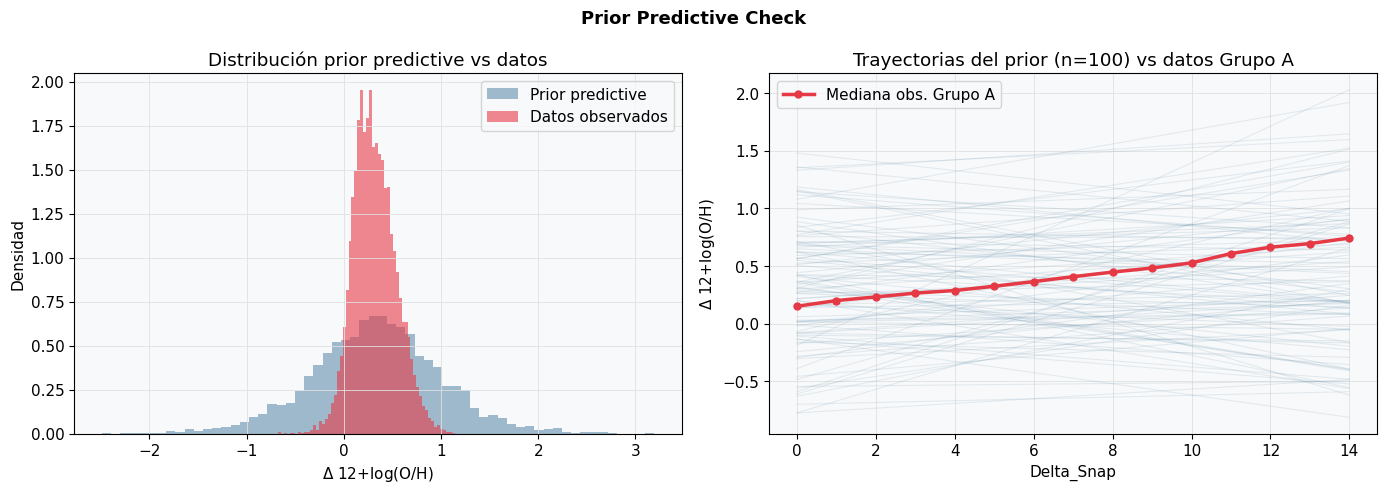

El prior es adecuado si las trayectorias envuelven los datos sin dominar la verosimilitud.


In [14]:
# ─── Muestreo del prior predictive ───────────────────────────────────────────
with modelo_bayesiano:
    prior_predictive = pm.sample_prior_predictive(draws=200, random_seed=RANDOM_SEED)

# ─── Visualización ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Prior Predictive Check", fontsize=13, fontweight="bold")

# Panel izq: distribución de y simulada vs observada
ax = axes[0]
prior_y = prior_predictive.prior_predictive["y"].values.flatten()
# Muestra aleatoria para no sobrecargar
sample_prior = np.random.choice(prior_y, size=5000, replace=False)
ax.hist(sample_prior, bins=60, density=True, alpha=0.5, color="#457B9D", label="Prior predictive")
ax.hist(y_obs, bins=60, density=True, alpha=0.6, color="#E63946", label="Datos observados")
ax.set_xlabel(r"$\Delta$ 12+log(O/H)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución prior predictive vs datos")
ax.legend()

# Panel der: trayectorias simuladas por Delta_Snap
ax = axes[1]
snaps_plot = np.arange(0, 15)
# Usamos muestras del prior para trazar trayectorias poblacionales
mu_alpha_samples = prior_predictive.prior["mu_alpha"].values.flatten()[:100]
beta_snap_samples = prior_predictive.prior["beta_snap"].values.flatten()[:100]
beta_merger_samples = prior_predictive.prior["beta_merger"].values.flatten()[:100]

snap_mean = df_post["Delta_Snap"].mean()
for i in range(100):
    traj = mu_alpha_samples[i] + beta_snap_samples[i] * (snaps_plot - snap_mean) + beta_merger_samples[i]
    ax.plot(snaps_plot, traj, alpha=0.12, color="#457B9D", linewidth=0.8)

# Mediana observada por snap (Grupo A como referencia)
df_a = df_post[df_post["Grupo"]=="A"]
med_obs = df_a.groupby("Delta_Snap")["12+log(O/H)_unif"].median()
ax.plot(med_obs.index, med_obs.values, color="#E63946", linewidth=2.5,
        marker="o", markersize=5, label="Mediana obs. Grupo A", zorder=5)
ax.set_xlabel("Delta_Snap")
ax.set_ylabel(r"$\Delta$ 12+log(O/H)")
ax.set_title("Trayectorias del prior (n=100) vs datos Grupo A")
ax.legend()

plt.tight_layout()
plt.show()
print("El prior es adecuado si las trayectorias envuelven los datos sin dominar la verosimilitud.")


## 4. Muestreo MCMC

Se utilizan 4 cadenas independientes con el algoritmo NUTS (No-U-Turn Sampler).

- **tune**: 1000 iteraciones de calentamiento
- **draws**: 2000 muestras efectivas por cadena → 8000 muestras totales
- **target_accept**: 0.9 para un paso de integración conservador

> ⏱️ El muestreo puede tomar varios minutos dependiendo del hardware.


In [15]:
with modelo_bayesiano:
    idata = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        progressbar=True,
    )

print("Muestreo completado.")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, tau_alpha, beta_snap, beta_merger, beta_AGN, beta_inter, beta_fgas, beta_mstar, alpha_gal, sigma]


Sampling 2 chains for 1_000 tune and 836 draw iterations (2_000 + 1_672 draws total) took 81 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Muestreo completado.


## 5. Diagnósticos de convergencia

Verificamos:
- **R-hat** < 1.01 en todos los parámetros (convergencia entre cadenas)
- **ESS** > 400 (tamaño efectivo de muestra)
- **Trace plots** para detectar no estacionaridad


In [ ]:
# ─── Tabla resumen de parámetros poblacionales ───────────────────────────────
params_pobla = ["mu_alpha", "tau_alpha", "beta_snap", "beta_merger",
                "beta_AGN", "beta_inter", "beta_fgas", "beta_mstar", "sigma"]

summary = az.summary(idata, var_names=params_pobla, round_to=4)
print("=== Resumen de parámetros poblacionales ===")
print(summary.to_string())

# Advertencia si R-hat > 1.01
rhat_max = summary["r_hat"].max()
if rhat_max < 1.01:
    print(f"✓ Convergencia OK: R-hat máximo = {rhat_max:.4f} (< 1.01)")
else:
    print(f"⚠ Revisar convergencia: R-hat máximo = {rhat_max:.4f} (>= 1.01)")


In [ ]:
# ─── Trace plots de los parámetros de interés ────────────────────────────────
az.plot_trace(
    idata,
    var_names=["beta_merger", "beta_AGN", "beta_inter", "beta_snap", "sigma"],
    combined=False,
    figsize=(14, 12),
)
plt.suptitle("Trace plots — parámetros poblacionales", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# ─── Forest plot: interceptos por grupo ──────────────────────────────────────
# Calculamos el intercepto efectivo por grupo sumando efectos
post = idata.posterior

efectos = {
    "A (Merger + AGN)":    post["mu_alpha"] + post["beta_merger"] + post["beta_AGN"] + post["beta_inter"],
    "B (No Merger + AGN)": post["mu_alpha"] + post["beta_AGN"],
    "C (Merger + NoAGN)":  post["mu_alpha"] + post["beta_merger"],
    "D (No Merger + NoAGN)": post["mu_alpha"],
}

fig, ax = plt.subplots(figsize=(10, 5))
colors_list = ["#E63946", "#457B9D", "#F4A261", "#2A9D8F"]
grupos_nombres = list(efectos.keys())

for i, (nombre, vals) in enumerate(efectos.items()):
    flat = vals.values.flatten()
    med  = np.median(flat)
    hdi  = az.hdi(flat, hdi_prob=0.94)
    ax.plot([hdi[0], hdi[1]], [i, i], color=colors_list[i], linewidth=4, alpha=0.7)
    ax.plot(med, i, "o", color=colors_list[i], markersize=10, zorder=5)
    ax.text(hdi[1]+0.005, i, f"{med:.3f} [{hdi[0]:.3f}, {hdi[1]:.3f}]",
            va="center", fontsize=10)

ax.set_yticks(range(len(grupos_nombres)))
ax.set_yticklabels(grupos_nombres, fontsize=11)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel(r"Intercepto efectivo $\Delta$ 12+log(O/H)  (HDI 94%)")
ax.set_title("Forest plot — metalicidad basal post-merger por grupo", fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Distribuciones posteriores de los parámetros de interés

Analizamos en detalle las posteriors de los efectos causales:
- **beta_merger**: efecto del merger sobre la metalicidad (independiente del AGN)
- **beta_AGN**: efecto del AGN sin merger
- **beta_inter**: efecto diferencial del AGN post-merger (interacción)

El contraste central es:

526\delta_{AGN} = \beta_{AGN} + \beta_{inter}526

que representa el efecto neto del AGN cuando hay un merger.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribuciones posteriores — parámetros poblacionales", fontsize=13, fontweight="bold")

params_plot = [
    ("beta_merger", r"$eta_{merger}$", "Efecto del merger",          "#F4A261"),
    ("beta_AGN",    r"$eta_{AGN}$",    "Efecto del AGN (sin merger)", "#457B9D"),
    ("beta_inter",  r"$eta_{inter}$",  "Interacción merger × AGN",   "#E63946"),
    ("beta_snap",   r"$eta_{snap}$",   "Pendiente temporal",          "#6A4C93"),
    ("beta_fgas",   r"$eta_{Fgas}$",   r"Efecto de {gas}$",        "#2A9D8F"),
    ("beta_mstar",  r"$eta_{M\star}$", r"Efecto de $\log M_\star$",  "#264653"),
]

for ax, (param, label, title, color) in zip(axes.flatten(), params_plot):
    samples = idata.posterior[param].values.flatten()
    hdi_94  = az.hdi(samples, hdi_prob=0.94)
    hdi_50  = az.hdi(samples, hdi_prob=0.50)
    med     = np.median(samples)

    # KDE
    kde_x = np.linspace(samples.min(), samples.max(), 500)
    kde   = stats.gaussian_kde(samples)
    kde_y = kde(kde_x)

    ax.plot(kde_x, kde_y, color=color, linewidth=2.5)

    # HDI 94%
    mask_94 = (kde_x >= hdi_94[0]) & (kde_x <= hdi_94[1])
    ax.fill_between(kde_x, kde_y, where=mask_94, alpha=0.20, color=color, label="HDI 94%")

    # HDI 50%
    mask_50 = (kde_x >= hdi_50[0]) & (kde_x <= hdi_50[1])
    ax.fill_between(kde_x, kde_y, where=mask_50, alpha=0.45, color=color, label="HDI 50%")

    ax.axvline(med,  color="black",  linewidth=1.8, linestyle="-",  label=f"Mediana={med:.3f}")
    ax.axvline(0,    color="gray",   linewidth=1.2, linestyle="--")
    ax.set_title(f"{title}
{label}", fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# ─── Contraste principal: efecto neto del AGN post-merger ────────────────────
delta_AGN_post_merger = (
    idata.posterior["beta_AGN"].values.flatten()
    + idata.posterior["beta_inter"].values.flatten()
)

hdi_delta = az.hdi(delta_AGN_post_merger, hdi_prob=0.94)
med_delta  = np.median(delta_AGN_post_merger)
prob_pos   = (delta_AGN_post_merger > 0).mean()
prob_neg   = (delta_AGN_post_merger < 0).mean()

print("=== Contraste central: δ_AGN = β_AGN + β_inter ===")
print(f"  Mediana:          {med_delta:.4f} dex")
print(f"  HDI 94%:          [{hdi_delta[0]:.4f}, {hdi_delta[1]:.4f}]")
print(f"  P(δ_AGN > 0):     {prob_pos:.3f}")
print(f"  P(δ_AGN < 0):     {prob_neg:.3f}")
print()
if hdi_delta[0] > 0:
    print("  → HDI 94% completamente por encima de 0: evidencia positiva de que el AGN post-merger AUMENTA la metalicidad.")
elif hdi_delta[1] < 0:
    print("  → HDI 94% completamente por debajo de 0: evidencia positiva de que el AGN post-merger REDUCE la metalicidad.")
else:
    print("  → HDI 94% incluye el 0: el efecto del AGN post-merger no es concluyente con el 94% de credibilidad.")

# Visualización del contraste
fig, ax = plt.subplots(figsize=(9, 5))
kde_x = np.linspace(delta_AGN_post_merger.min(), delta_AGN_post_merger.max(), 500)
kde   = stats.gaussian_kde(delta_AGN_post_merger)
kde_y = kde(kde_x)
ax.plot(kde_x, kde_y, color="#E63946", linewidth=2.5)
mask  = (kde_x >= hdi_delta[0]) & (kde_x <= hdi_delta[1])
ax.fill_between(kde_x, kde_y, where=mask, alpha=0.30, color="#E63946", label=f"HDI 94% [{hdi_delta[0]:.3f}, {hdi_delta[1]:.3f}]")
ax.axvline(med_delta, color="black",  linewidth=2, linestyle="-",  label=f"Mediana = {med_delta:.3f} dex")
ax.axvline(0,         color="gray",   linewidth=1.5, linestyle="--", label="Efecto nulo")
ax.set_xlabel(r"$\delta_{AGN} = eta_{AGN} + eta_{inter}$  [dex]")
ax.set_ylabel("Densidad posterior")
ax.set_title(r"Posterior del efecto neto del AGN post-merger ($\delta_{AGN}$)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Posterior Predictive Check (PPC)

Verificamos que el modelo reproduce las distribuciones observadas y la
evolución temporal de la metalicidad por grupo.


In [ ]:
# ─── Muestreo posterior predictive ──────────────────────────────────────────
with modelo_bayesiano:
    ppc = pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False)

print("PPC listo.")


In [ ]:
# ─── PPC 1: distribución marginal de y ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Posterior Predictive Check", fontsize=13, fontweight="bold")

ax = axes[0]
ppc_y = ppc.posterior_predictive["y"].values
# Graficar 200 réplicas
for i in range(min(200, ppc_y.shape[0]*ppc_y.shape[1])):
    chain = i // ppc_y.shape[1]
    draw  = i %  ppc_y.shape[1]
    ax.hist(ppc_y[chain, draw], bins=50, density=True,
            alpha=0.03, color="#457B9D", histtype="step")
ax.hist(y_obs, bins=50, density=True, color="#E63946", alpha=0.8,
        label="Datos observados", histtype="step", linewidth=2)
ax.set_xlabel(r"$\Delta$ 12+log(O/H)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución marginal: PPC (azul) vs datos (rojo)")
ax.legend()

# ─── PPC 2: evolución temporal por grupo ────────────────────────────────────
ax = axes[1]
ppc_flat = ppc.posterior_predictive["y"].values.reshape(-1, len(y_obs))
ppc_mean  = ppc_flat.mean(axis=0)

df_ppc = df_post.copy()
df_ppc["y_pred_mean"] = ppc_mean

for g in "ABCD":
    sub_obs  = df_ppc[df_ppc["Grupo"]==g].groupby("Delta_Snap")["12+log(O/H)_unif"].median()
    sub_pred = df_ppc[df_ppc["Grupo"]==g].groupby("Delta_Snap")["y_pred_mean"].median()
    ax.plot(sub_obs.index,  sub_obs.values,  color=COLORS[g], linewidth=2.5,
            marker="o", markersize=5, label=f"{LABELS[g]} (obs)")
    ax.plot(sub_pred.index, sub_pred.values, color=COLORS[g], linewidth=1.8,
            linestyle="--", alpha=0.8)

ax.set_xlabel("Delta_Snap")
ax.set_ylabel(r"Mediana $\Delta$ 12+log(O/H)")
ax.set_title("Evolución temporal: obs (sólido) vs PPC (punteado)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## 8. Comparación de modelos

Comparamos el modelo completo contra dos modelos anidados:

- **M1 (completo):** incluye merger, AGN e interacción
- **M2 (sin interacción):** excluye el término $\beta_{inter}$
- **M3 (sin AGN):** excluye $\beta_{AGN}$ y $\beta_{inter}$

Usamos **WAIC** (Widely Applicable Information Criterion) y **LOO-CV** como criterios de comparación.


In [ ]:
# ─── Modelo sin interacción (M2) ─────────────────────────────────────────────
with pm.Model() as modelo_sin_inter:

    mu_alpha  = pm.Normal("mu_alpha",  mu=0.25, sigma=0.3)
    tau_alpha = pm.HalfNormal("tau_alpha", sigma=0.3)
    beta_snap   = pm.Normal("beta_snap",   mu=0.0, sigma=0.05)
    beta_merger = pm.Normal("beta_merger", mu=0.0, sigma=0.3)
    beta_AGN    = pm.Normal("beta_AGN",    mu=0.0, sigma=0.3)
    beta_fgas   = pm.Normal("beta_fgas",   mu=0.0, sigma=0.3)
    beta_mstar  = pm.Normal("beta_mstar",  mu=0.0, sigma=0.3)
    alpha_gal   = pm.Normal("alpha_gal",   mu=mu_alpha, sigma=tau_alpha, shape=N_galaxias)
    sigma       = pm.HalfNormal("sigma",   sigma=0.3)

    mu = (alpha_gal[gal_idx_vec]
          + beta_snap   * snap_c
          + beta_merger * merger_idx
          + beta_AGN    * agn_idx
          + beta_fgas   * fgas_c
          + beta_mstar  * mstar_c)

    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)

    idata_m2 = pm.sample(
        draws=2000, tune=1000, chains=4,
        target_accept=0.9, random_seed=RANDOM_SEED, progressbar=True
    )

print("Modelo M2 (sin interacción) muestreado.")


In [ ]:
# ─── Modelo sin AGN (M3) ─────────────────────────────────────────────────────
with pm.Model() as modelo_sin_AGN:

    mu_alpha  = pm.Normal("mu_alpha",  mu=0.25, sigma=0.3)
    tau_alpha = pm.HalfNormal("tau_alpha", sigma=0.3)
    beta_snap   = pm.Normal("beta_snap",   mu=0.0, sigma=0.05)
    beta_merger = pm.Normal("beta_merger", mu=0.0, sigma=0.3)
    beta_fgas   = pm.Normal("beta_fgas",   mu=0.0, sigma=0.3)
    beta_mstar  = pm.Normal("beta_mstar",  mu=0.0, sigma=0.3)
    alpha_gal   = pm.Normal("alpha_gal",   mu=mu_alpha, sigma=tau_alpha, shape=N_galaxias)
    sigma       = pm.HalfNormal("sigma",   sigma=0.3)

    mu = (alpha_gal[gal_idx_vec]
          + beta_snap   * snap_c
          + beta_merger * merger_idx
          + beta_fgas   * fgas_c
          + beta_mstar  * mstar_c)

    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)

    idata_m3 = pm.sample(
        draws=2000, tune=1000, chains=4,
        target_accept=0.9, random_seed=RANDOM_SEED, progressbar=True
    )

print("Modelo M3 (sin AGN) muestreado.")


In [ ]:
# ─── Comparación WAIC + LOO ───────────────────────────────────────────────────
# Añadir log-verosimilitud puntual a cada idata
with modelo_bayesiano:  idata    = pm.compute_log_likelihood(idata)
with modelo_sin_inter:  idata_m2 = pm.compute_log_likelihood(idata_m2)
with modelo_sin_AGN:    idata_m3 = pm.compute_log_likelihood(idata_m3)

comparacion = az.compare(
    {"M1 completo": idata, "M2 sin interacción": idata_m2, "M3 sin AGN": idata_m3},
    ic="loo",
    scale="log",
)

print("=== Comparación de modelos por LOO-CV ===")
print(comparacion.to_string())

# Gráfico de comparación
az.plot_compare(comparacion, figsize=(10, 4))
plt.title("Comparación de modelos — LOO-CV", fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Efectos aleatorios por galaxia

Exploramos la variabilidad intrínseca entre galaxias (interceptos $\alpha_{gal}$)
para entender qué fracción de la varianza en metalicidad se explica por
la heterogeneidad de la población vs. los efectos fijos del modelo.


In [ ]:
# ─── Distribución de interceptos por galaxia ─────────────────────────────────
alpha_gal_post = idata.posterior["alpha_gal"].values  # (chain, draw, N_gal)
alpha_gal_med  = np.median(alpha_gal_post, axis=(0,1))  # mediana por galaxia
alpha_gal_std  = np.std(alpha_gal_post, axis=(0,1))

# Asignar grupo a cada galaxia
gal_grupo = (
    df_post.drop_duplicates("gal_idx")
    .set_index("gal_idx")[["Grupo"]]
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Efectos aleatorios por galaxia (interceptos α_gal)", fontsize=13, fontweight="bold")

# Distribución de medianas por grupo
ax = axes[0]
for g in "ABCD":
    idx_g = gal_grupo[gal_grupo["Grupo"]==g].index
    ax.hist(alpha_gal_med[idx_g], bins=30, alpha=0.6,
            color=COLORS[g], label=LABELS[g], edgecolor="white")
ax.set_xlabel(r"Mediana posterior de $lpha_{gal}$")
ax.set_ylabel("N galaxias")
ax.set_title("Distribución de interceptos por grupo")
ax.legend(fontsize=9)

# Incertidumbre por galaxia (std posterior) vs mediana
ax = axes[1]
for g in "ABCD":
    idx_g = gal_grupo[gal_grupo["Grupo"]==g].index
    ax.scatter(alpha_gal_med[idx_g], alpha_gal_std[idx_g],
               color=COLORS[g], alpha=0.4, s=15, label=LABELS[g])
ax.set_xlabel(r"Mediana posterior de $lpha_{gal}$")
ax.set_ylabel(r"Desviación estándar posterior de $lpha_{gal}$")
ax.set_title("Incertidumbre por galaxia")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ─── Fracción de varianza explicada por los efectos aleatorios ───────────────
tau_alpha_med = np.median(idata.posterior["tau_alpha"].values)
sigma_med     = np.median(idata.posterior["sigma"].values)
icc = tau_alpha_med**2 / (tau_alpha_med**2 + sigma_med**2)

print("=== Intraclass Correlation Coefficient (ICC) ===")
print(f"  tau_alpha (mediana): {tau_alpha_med:.4f}")
print(f"  sigma     (mediana): {sigma_med:.4f}")
print(f"  ICC = tau² / (tau² + sigma²) = {icc:.3f}")
print(f"  → El {icc*100:.1f}% de la varianza total se explica por diferencias entre galaxias")


## 10. Resumen de resultados


In [ ]:
# ─── Tabla resumen final ─────────────────────────────────────────────────────
params_res = ["beta_merger", "beta_AGN", "beta_inter", "beta_snap",
              "beta_fgas", "beta_mstar", "mu_alpha", "tau_alpha", "sigma"]

resumen = az.summary(idata, var_names=params_res,
                     stat_funcs={"mediana": np.median},
                     extend=True, hdi_prob=0.94, round_to=4)

print("=== Tabla resumen — parámetros del modelo completo (M1) ===")
print(resumen[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk"]].to_string())

print("
=== Contraste δ_AGN = β_AGN + β_inter ===")
delta_AGN = (
    idata.posterior["beta_AGN"].values.flatten()
    + idata.posterior["beta_inter"].values.flatten()
)
hdi_d = az.hdi(delta_AGN, hdi_prob=0.94)
print(f"  Mediana: {np.median(delta_AGN):.4f} dex")
print(f"  HDI 94%: [{hdi_d[0]:.4f}, {hdi_d[1]:.4f}]")
print(f"  P(δ>0):  {(delta_AGN>0).mean():.3f}")

print("
=== Modelo ganador (LOO-CV) ===")
print(comparacion[["elpd_loo","p_loo","d_loo","weight"]].to_string())
